In [ ]:
!pip install ultralytics roboflow

# Objected Detection using YOLO

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from collections import Counter
import random

from ultralytics import YOLO
from roboflow import Roboflow


from google.colab.patches import cv2_imshow
from google.colab import userdata

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Problem Definition
- Task type: Detection
- Objective: Detect licence plate of a vehical

## Dataset + EDA

In [ ]:
rf = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY'))
project = rf.workspace("chetan-sharma-n4cau").project("license-plate-recognition-rxg4e-qrnuh")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to License-Plate-Recognition-1 in yolov11:: 100%|██████████| 20255/20255 [00:03<00:00, 6392.58it/s]


In [ ]:
data_path = '/content/License-Plate-Recognition-1'
train_path = os.path.join(data_path, 'train')
valid_path = os.path.join(data_path, 'valid')
test_path = os.path.join(data_path, 'test')
train_labels = os.path.join(train_path, 'labels')

image_dir, label_dir = f"{train_path}/images", f"{train_path}/labels"

In [ ]:
splits = ['train', 'valid', 'test']

for split in splits:
  img_path = os.path.join(data_path, split, 'images')
  label_path = os.path.join(data_path, split, 'labels')

  num_images = len(os.listdir(img_path))
  num_labels = len(os.listdir(label_path))

  print(f"{split.upper()}:")
  print(f"Images: {num_images}, Labels: {num_labels}")

TRAIN:
Images: 7057, Labels: 7057
VALID:
Images: 2048, Labels: 2048
TEST:
Images: 1020, Labels: 1020


In [ ]:
counter = Counter()
for file in os.listdir(train_labels):
  with open(os.path.join(train_labels, file), 'r') as f:
    for line in f.readlines():
      cls = int(line.split()[0])
      counter[cls] += 1

print("Class Distribution:", counter)

Class Distribution: Counter({0: 7357})


In [ ]:
widths = []
heights = []

for file in os.listdir(train_labels):
  with open(os.path.join(train_labels, file), 'r') as f:
    for line in f.readlines():
      _, _, _, w, h = map(float, line.split())
      widths.append(w)
      heights.append(h)

print("Width mean:", np.mean(widths))
print("Height mean:", np.mean(heights))

Width mean: 0.19990474633002583
Height mean: 0.15032505182139458


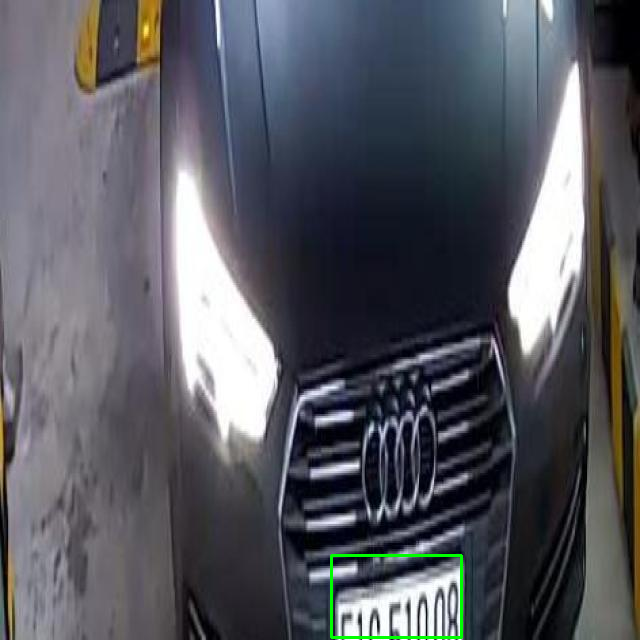

In [ ]:
img_file = random.choice(os.listdir(image_dir))

img_path = os.path.join(image_dir, img_file)
label_path = os.path.join(label_dir, img_file.replace('.jpg', '.txt'))

img = cv2.imread(img_path)
h, w, _ = img.shape

with open(label_path, 'r') as f:
  for line in f.readlines():
    cls, x, y, bw, bh = map(float, line.split())

    x1 = int((x - bw/2) * w)
    y1 = int((y - bh/2) * h)
    x2 = int((x + bw/2) * w)
    y2 = int((y + bh/2) * h)

    cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)

    cv2_imshow(img)

In [ ]:
missing = []

for img in os.listdir(image_dir):
  label = img.replace('.jpg', '.txt')
  if not os.path.exists(os.path.join(label_dir, label)):
    missing.append(img)

print("Missing labels:", len(missing))

Missing labels: 0


In [ ]:
empty = 0

for file in os.listdir(label_dir):
  if os.path.getsize(os.path.join(label_dir, file)) == 0:
    empty += 1

print("Empty label files:", empty)

Empty label files: 5


### EDA Findings
- **Dataset Split:**
  - Training set: 7057 images and 7057 labels.
  - Validation set: 2048 images and 2048 labels.
  - Test set: 1020 images and 1020 labels.
- **Class Distribution:** The dataset contains a single class (class `0`) with 7357 instances across the training set, therefore it's a single-object detection task (i.e., license plates).
- **Bounding Box Dimensions:**
  - Average normalized width of bounding boxes: ~0.20
  - Average normalized height of bounding boxes: ~0.15
- **Data Integrity:**
  - No missing label files were found for the images.
  - 5 empty label files were identified, meaning 5 images in the training set do not have any annotations.

## Preprocessing + Augmentation
- auto scaling done in robo flow
- images are resized to 640*640 in roboflow

In [ ]:
empty_label_files = []
for file in os.listdir(label_dir):
  label_filepath = os.path.join(label_dir, file)
  if os.path.getsize(label_filepath) == 0:
    empty_label_files.append(file)

print(f"Found {len(empty_label_files)} empty label files to remove.")

for label_file in empty_label_files:
  label_filepath = os.path.join(label_dir, label_file)
  image_file = label_file.replace('.txt', '.jpg')
  image_filepath = os.path.join(image_dir, image_file)

  if os.path.exists(label_filepath):
    os.remove(label_filepath)
    print(f"Removed empty label file: {label_filepath}")
  if os.path.exists(image_filepath):
    os.remove(image_filepath)
    print(f"Removed corresponding image file: {image_filepath}")

Found 5 empty label files to remove.
Removed empty label file: /content/License-Plate-Recognition-1/train/labels/1649292507312_jpg.rf.4e5970afdc595c67cd97bed9aab18853.txt
Removed corresponding image file: /content/License-Plate-Recognition-1/train/images/1649292507312_jpg.rf.4e5970afdc595c67cd97bed9aab18853.jpg
Removed empty label file: /content/License-Plate-Recognition-1/train/labels/image10_jpeg_jpg.rf.4c8edfc48f775be984ca7a67afedfb9c.txt
Removed corresponding image file: /content/License-Plate-Recognition-1/train/images/image10_jpeg_jpg.rf.4c8edfc48f775be984ca7a67afedfb9c.jpg
Removed empty label file: /content/License-Plate-Recognition-1/train/labels/images6_jpg.rf.fb23417010c0a6c8fbf1dab835e0afc4.txt
Removed corresponding image file: /content/License-Plate-Recognition-1/train/images/images6_jpg.rf.fb23417010c0a6c8fbf1dab835e0afc4.jpg
Removed empty label file: /content/License-Plate-Recognition-1/train/labels/lede-licenseplates_jpg.rf.d787277b15647b7d54dae79efb1e4df4.txt
Removed co

- images with missing labels have been removed

## Model + Config

- Model: yolo 11 (ultralytics)

>Why YOLO?
> - Real-time detection
>- Single-stage → faster than R-CNN
> - Good balance of speed & accuracy

In [ ]:
model = YOLO('yolo11n.pt')

## Training

In [ ]:
results = model.train(
    data=f"{data_path}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    lr0=0.01,
    optimizer="Adam",
    device=0,
    workers=4, # paraller processing kaggle provides 4 cores cpu
    patience=10,
    augment=True
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/License-Plate-Recognition-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=10,

## Evaluation and visualization

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1532.4±719.6 MB/s, size: 38.8 KB)
val: Scanning /content/License-Plate-Recognition-1/valid/labels.cache... 2048 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2048/2048 477.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 6.6it/s 19.5s
                   all       2048       2195      0.963      0.932      0.965      0.659
Speed: 1.0ms preprocess, 3.8ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d7375354b60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_res

In [ ]:
print("mAP@50:", metrics.box.map50)
print("mAP@50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

mAP@50: 0.9647718701303256
mAP@50-95: 0.6590239539160955
Precision: 0.9632804460791877
Recall: 0.9322136170691772


In [ ]:
metrics.confusion_matrix.plot(save_dir=".")

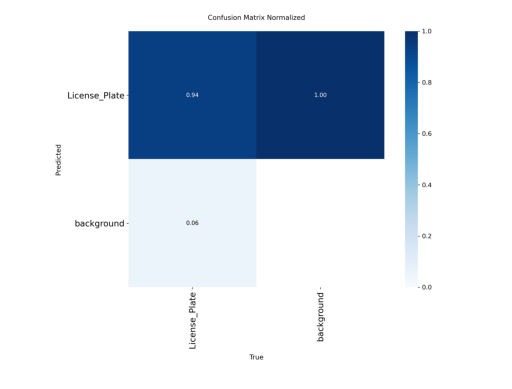

In [ ]:
img = cv2.imread('confusion_matrix_normalized.png')

if img is not None:
  plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
  plt.axis('off')
  plt.show()

### Inference

In [ ]:
model.save('yolo_detection_numberplate.pt')

In [ ]:
model = YOLO("runs/detect/train/weights/best.pt")
model.export(format="onnx")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.2 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 1.4s, saved as 'runs/detect/train/weights/best.onnx' (10.1 MB)

Export complete (2.5s)
Results saved to /content/runs/detect/train/weights
Predict:         yolo predict task=detect model=runs/detect/train/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/detect/train/weights/best.onnx imgsz=640 data=/content/License-Plate-Recognition-1/data.yaml  
Visualize:       https://netron.app


'runs/detect/train/weights/best.onnx'

In [ ]:
results = model.predict("./AA1XUJdX.jpeg", conf=0.5, save=True)


image 1/1 /content/AA1XUJdX.jpeg: 384x640 2 License_Plates, 21.8ms
Speed: 1.7ms preprocess, 21.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict2


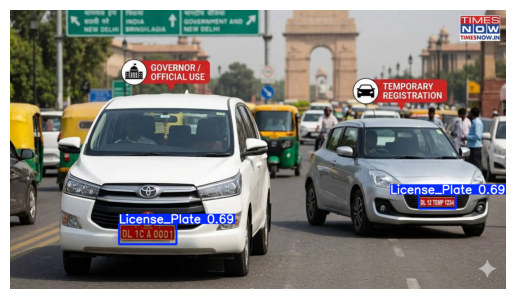

In [ ]:
img = results[0].plot()

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## Conclusion

- **High Performance**: The YOLOv11 model achieved strong performance metrics, with `mAP@50` of `0.965` and `mAP@50-95` of `0.659`, indicating its effectiveness in detecting license plates.
- **Robustness**: A precision of `0.963` and recall of `0.932` suggest the model is both accurate in its predictions and capable of identifying most positive instances.
- **Data Handling**: The initial data exploration identified and addressed 5 empty label files, ensuring data quality for training.
- **Single Class Focus**: The model was specifically trained for a single object class (license plates), which simplifies the task and allows for focused optimization.

# Integration OCR model to read Content of number plate



In [ ]:
!pip install -U transformers

In [ ]:
from transformers import AutoProcessor, AutoModelForImageTextToText
import os
from huggingface_hub import InferenceClient
import torch


import base64
from io import BytesIO
from PIL import Image
import re

In [ ]:
MODEL_PATH = "zai-org/GLM-OCR"
ocr_processor = AutoProcessor.from_pretrained(MODEL_PATH)
ocr_model = AutoModelForImageTextToText.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
    torch_dtype="auto",
    device_map="auto",
)

def pil_to_base64(pil_image: Image.Image) -> str:
    buffered = BytesIO()
    pil_image.save(buffered, format="PNG")
    return base64.b64encode(buffered.getvalue()).decode()

def recognize_license_plate_text(image_obj: Image.Image) -> str:
    base64_image = pil_to_base64(image_obj)
    messages_for_ocr = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image_url": {"url": f"data:image/png;base64,{base64_image}"}
                },
                {
                    "type": "text",
                    "text": "Text Recognition:"
                }
            ],
        }
    ]
    inputs = ocr_processor.apply_chat_template(
        messages_for_ocr,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    ).to(ocr_model.device)
    inputs.pop("token_type_ids", None)
    generated_ids = ocr_model.generate(**inputs, max_new_tokens=100)
    output_text = ocr_processor.decode(generated_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

    # Enhanced cleaning to remove markdown and model-specific tags
    cleaned = output_text.replace("Text Recognition:", "")
    cleaned = re.sub(r'```(?:markdown)?', '', cleaned)
    cleaned = cleaned.replace("```", "").replace("<|user|>", "").strip()
    return cleaned

In [ ]:
def get_car_numbers(image_path: str) -> list[str]:
    yolo_model = YOLO("/content/number_plate_detection.pt")

    # Perform prediction on the image
    results = yolo_model.predict(image_path, conf=0.5, save=False)

    original_image_pil = Image.open(image_path).convert("RGB")

    recognized_plates = []

    # Iterate through each detected license plate
    for r in results:
        if r.boxes.xyxy.numel() > 0: # Check if any boxes were detected
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])

                # Crop the license plate from the original PIL image
                cropped_plate_pil = original_image_pil.crop((x1, y1, x2, y2))

                # Recognize text using the GLM-OCR model
                recognized_text = recognize_license_plate_text(cropped_plate_pil)
                recognized_plates.append(recognized_text)
        else:
            print(f"No license plates detected in {image_path}.")

    return recognized_plates

In [ ]:
print("Processing image to get car numbers...")
car_numbers = get_car_numbers("./AA1XUJdX.jpg")

if car_numbers:
    print("Recognized Car Numbers:")
    for i, number in enumerate(car_numbers):
        print(f"Plate {i+1}: {number}")
else:
    print("No car numbers found.")

Processing image to get car numbers...

image 1/1 /content/AA1XUJdX.jpg: 384x640 3 License_Plates, 11.8ms
Speed: 2.3ms preprocess, 11.8ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
Recognized Car Numbers:
Plate 1: 
Plate 2: 
Plate 3: 
